# Studies of random matrices their singular value decompositions

Construct some matrices from sampling their distributions and look at the impact of changing the distribution on the SVD. This mostly involves developing intuition for results from Random Matrix Theory.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import math
from scipy.stats import differential_entropy

## Helper functions to generate matrix ensembles

In [2]:
sv_bins = np.array([0]) + np.linspace(1e-4, 10 + 1e-4, 51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]
w_bins = np.linspace(-5, 5, 41)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]


def generate_full_rank(d_n, mu=0, sigma=1):
    h = np.random.normal(loc=mu, scale=sigma, size=d_n * d_n)
    W_QK = h.reshape(d_n, d_n) / np.sqrt(d_n)
    _, S, _ = torch.linalg.svd(torch.tensor(W_QK))
    P_w, _ = np.histogram(h, w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)


def generate_low_rank(d_n, d_m, mu=0, sigma=1):
    W_Q = np.random.normal(loc=mu, scale=sigma, size=d_n * d_m).reshape(d_n, d_m)
    W_K = np.random.normal(loc=mu, scale=sigma, size=d_n * d_m).reshape(d_m, d_n)
    W_QK = W_Q @ W_K / np.sqrt(d_n)
    _, S, _ = torch.linalg.svd(torch.tensor(W_QK))
    P_w, _ = np.histogram(W_QK.flatten(), w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)


def average_curves(func, n_samp=10, **kwargs):
    results = [func(**kwargs) for _ in range(n_samp)]
    x_list, y_list, z_list = zip(*results)
    x_avg = torch.stack(x_list).mean(dim=0)
    y_avg = torch.stack(y_list).mean(dim=0)
    z_avg = torch.stack(z_list).mean(dim=0)
    return (x_avg, y_avg, z_avg)


def draw_trio(func, **kwargs):
    _, axes = plt.subplots(1, 3, figsize=(12, 3))
    sv, arr, spec = average_curves(func, **kwargs)

    axes[0].plot(w_centers, arr)
    axes[0].set_xlabel("W")
    axes[0].set_ylabel("P(W)")

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("SV")
    axes[1].set_yscale("log")

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("SV")
    axes[2].set_ylabel("P(SV)")
    axes[2].set_yscale("log")

    plt.tight_layout()
    plt.show()

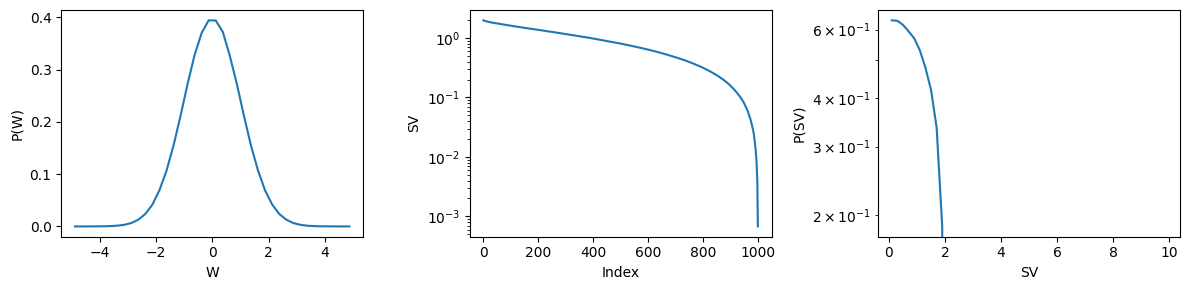

In [3]:
draw_trio(generate_full_rank, d_n=1000, n_samp=5)

## Singular value distributions and spectral densities

### Full rank - varying $\sigma$

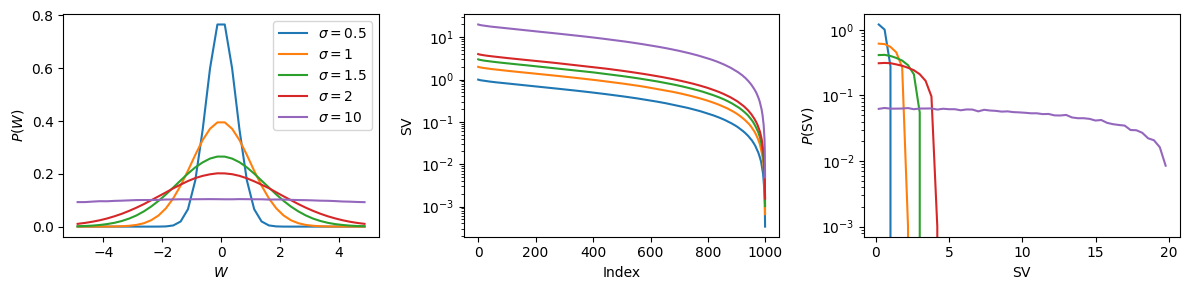

In [4]:
d_n = 1000
d_m = 500
_, axes = plt.subplots(1, 3, figsize=(12, 3))
w_bins = np.linspace(-5, 5, 41)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]

sv_bins = np.array([-1e-2]) + np.linspace(1e-4, 20 + 1e-4, 51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]

h_full_rank = {}
for sigma in [0.5, 1, 1.5, 2, 10]:
    sv, arr, spec = average_curves(generate_full_rank, d_n=d_n, sigma=sigma)

    name = f"$\sigma = {sigma}$"
    axes[0].plot(w_centers, arr, label=name)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")
    axes[0].legend()

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\mathrm{SV}$")
    axes[1].set_yscale("log")

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("$\mathrm{SV}$")
    axes[2].set_ylabel("$P(\mathrm{SV})$")
    axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

### Low rank - varying $\sigma$ at fixed $d_n / d_m = 2$

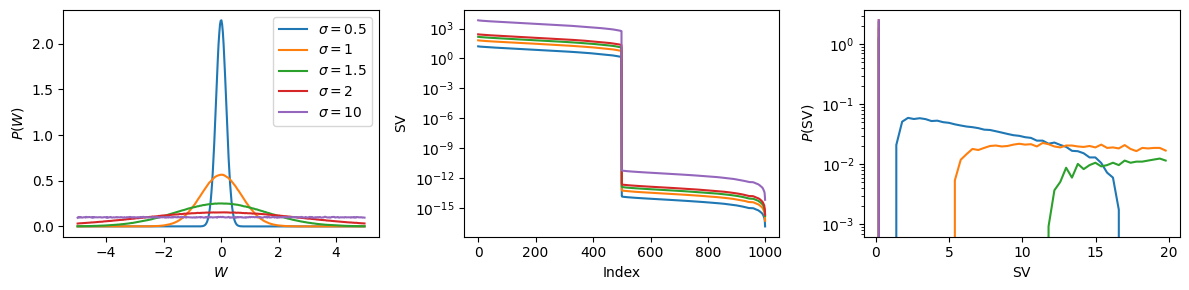

In [5]:
d_n = 1000
d_m = 500
w_bins = np.linspace(-5, 5, 401)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]

_, axes = plt.subplots(1, 3, figsize=(12, 3))
h_low_rank = {}
for sigma in [0.5, 1, 1.5, 2, 10]:
    sv, arr, spec = average_curves(generate_low_rank, d_n=d_n, d_m=d_m, sigma=sigma)

    name = f"$\sigma = {sigma}$"
    axes[0].plot(w_centers, arr, label=name)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")
    axes[0].legend()

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\mathrm{SV}$")
    axes[1].set_yscale("log")

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("$\mathrm{SV}$")
    axes[2].set_ylabel("$P(\mathrm{SV})$")
    axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

### Low rank - $\sigma = 1$ varying $d_n / d_m = 0.1, 0.2, \cdots 1$

Also showing full rank. 

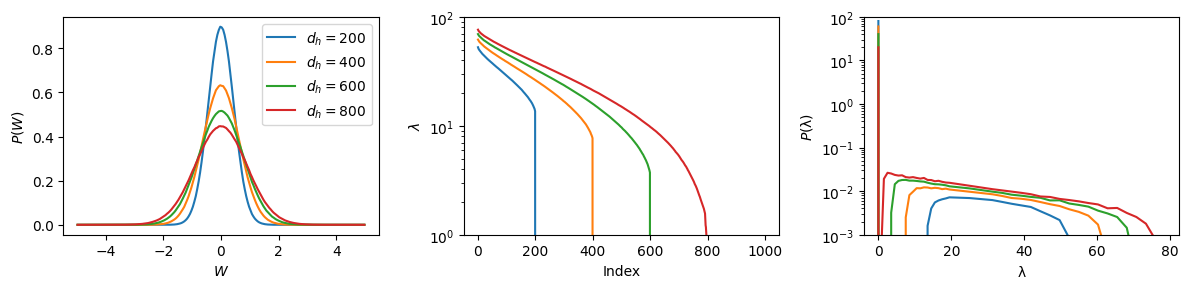

In [6]:
d_n = 1000
d_step = 200
sigma = 1
w_bins = np.linspace(-5, 5, 201)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.concat([np.linspace(0,1e-2,2),np.linspace(2e-2, 20, 21),np.linspace(30, 80, 20)])
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]

h_out = {}
single_count_density = 1.0 / (d_n * sv_dx)
_, axes = plt.subplots(1, 3, figsize=(12, 3))
sigma_empirical = []
for d_m in range(d_step, d_n + d_step - d_step, d_step):
    sv, arr, spec = average_curves(generate_low_rank, d_n=d_n, d_m=d_m, sigma=sigma)

    name = f"$d_h = {d_m}$"
    axes[0].plot(w_centers, arr, label=name)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")
    axes[0].legend()
    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\lambda$")
    axes[1].set_yscale("log")
    axes[1].set_ylim(bottom=1, top=100)
    line = axes[2].plot(sv_centers, spec)[0]
    color = line.get_color()
    axes[2].set_xlabel("$\mathrm{\lambda}$")
    axes[2].set_ylabel("$P(\mathrm{\lambda})$")
    axes[2].set_yscale("log")
    axes[2].set_ylim(bottom=single_count_density * 0.01, top=100)
plt.tight_layout()
plt.show()

### Two Gaussians
Model is now $x ~ f N(0,1) + (1-f)N(\mu, \sigma)$
First we evaluate at fixed $f$, choosing $\mu ~0$ and $\sigma >> 1$. This has the effect of adding a nearly uniform component to the distribution but without the usual effects from the finite domain of the Uniform distribution.

In [7]:
def sample_mixture(
    d_n, mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=2.0, f=0.5, binomial=False, device="cpu"
):
    n = d_n * d_n
    if binomial:
        n2 = int(
            torch.binomial(
                torch.tensor(n, dtype=torch.float32), torch.tensor(float(f))
            ).item()
        )
    else:
        n2 = int(f * n)
    n1 = n - n2
    dev = torch.device(device)
    samples1 = torch.normal(mu1, sigma1, size=(n1,), device=dev)
    samples2 = torch.normal(mu2, sigma2, size=(n2,), device=dev)

    samples = torch.cat([samples1, samples2])
    samples = samples[torch.randperm(n, device=dev)]
    _, S, _ = torch.linalg.svd(samples.reshape(d_n, d_n))
    P_w, _ = np.histogram(samples, w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)

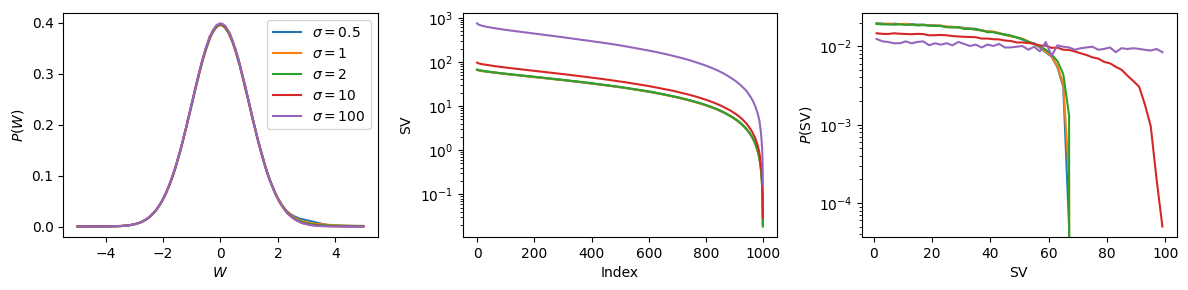

In [8]:
d_n = 1000
d_step = 200
w_bins = np.linspace(-5, 5, 201)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.linspace(0, 100, 51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]

h_out = {}
single_count_density = 1.0 / (d_n * sv_dx)
_, axes = plt.subplots(1, 3, figsize=(12, 3))

for sigma in [0.5, 1, 2, 10, 100]:
    sv, arr, spec = average_curves(
        sample_mixture, d_n=d_n, mu2=3, sigma2=sigma, f=0.01, binomial=True
    )

    name = f"$\sigma = {sigma}$"
    axes[0].plot(w_centers, arr, label=name)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")
    axes[0].legend()

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\mathrm{SV}$")
    axes[1].set_yscale("log")
    # axes[1].set_xlim(left=0, right=10)

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("$\mathrm{SV}$")
    axes[2].set_ylabel("$P(\mathrm{SV})$")
    axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

### Nested block structures
- Nesting recursively $A_{n+1}$ = $A_{n} \otimes A_{n}$
    - Dimension blows up quickly, matrices are $n^{2m} \times n^{2m}$
- Nesting with self: $W = A \otimes A \otimes \cdots A$, where $A$ is a single $n\times n$ matrix multiplied $m$ times.
- Nesting with a new matrix each time: $W = A_0 \otimes A_1 \otimes \cdots A_m$ where the $A_i$'s are separate random matrices


Simplification use $A_i = \mathbf{R}(\theta_i)$. Parameterize the matrix by random angles.


In [9]:
def generate_nested_blocks(d_h, n_h, nested=False):
    A = torch.tensor(np.random.normal(size=(d_h, d_h)))
    # theta = torch.rand(1) * 2 * math.pi
    # c, s = torch.cos(theta), torch.sin(theta)
    # A = torch.tensor([[c, -s], [s, c]])
    # A = torch.tensor(np.arange(d_h*d_h).reshape(d_h,d_h))
    for idx in range(n_h):
        B = A
        if nested:
            # B = torch.tensor(np.random.normal(size=(d_h, d_h)))
            theta = torch.rand(1) * 2 * math.pi
            print(f"Theta {idx}: {theta.item():.2f}")

            c, s = torch.cos(theta), torch.sin(theta)
            A = torch.tensor([[c, -s], [s, c]])
        A = torch.kron(A, B)

    _, S, _ = torch.linalg.svd(A)
    P_w, _ = np.histogram(A.flatten(), w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)


gnb = generate_nested_blocks(2, 3)

In [10]:
# def generate_blocks(d_h, n_h, rotation=False, nested=False):
#     M = torch.tensor(np.random.normal(size=(d_h, d_h)))
#     A = torch.tensor(M)
#     for idx in range(n_h):
#         A = torch.kron(A, M)

#     _, S, _ = torch.linalg.svd(A)
#     P_w,_ = np.histogram(A.flatten(), w_bins, density = True)
#     P_s,_ = np.histogram(S, sv_bins, density = True)
#     return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)
# gnb = generate_nested_blocks(2, 3)

### Using $SO(n)$ symmetry
$\mathbf{W} = \sum_g A_g \mathbf{T}_g$ where $\mathbf{T}$ are the generators of $SO(n)$, $n\times n$ anti-symmetric matrices. There are $n(n-1)/2$ generators.

In [11]:
def so_n_generators(n):
    """Generate all basis elements for the Lie algebra so(n)"""
    generators = []

    for i in range(n):
        for j in range(i + 1, n):
            L = torch.zeros(n, n)
            L[i, j] = 1
            L[j, i] = -1
            generators.append(L)

    return generators


def random_so_n_element(n):
    """Create random antisymmetric matrix as linear combination of generators"""
    generators = so_n_generators(n)
    d = len(generators)  # n(n-1)/2

    # Random coefficients
    A = torch.randn(d)

    # Linear combination
    M = torch.zeros(n, n)
    for i, coeff in enumerate(A):
        M += coeff * generators[i]

    return M, A, generators


# Example
n = 4
M, coeffs, gens = random_so_n_element(n)

print(f"Random so({n}) element:")
print(M)
print(f"\nCoefficients shape: {coeffs.shape}")
print(f"Is antisymmetric? {torch.allclose(M, -M.T)}")


def generate_so_n(d_n):
    M, _, _ = random_so_n_element(n=d_n)
    _, S, _ = torch.linalg.svd(M)
    P_w, _ = np.histogram(M.flatten(), w_bins, density=True)
    P_s, _ = np.histogram(S, sv_bins, density=True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)

Random so(4) element:
tensor([[ 0.0000,  0.8193, -1.0969,  0.4291],
        [-0.8193,  0.0000, -0.0488, -0.1946],
        [ 1.0969,  0.0488,  0.0000, -0.8290],
        [-0.4291,  0.1946,  0.8290,  0.0000]])

Coefficients shape: torch.Size([6])
Is antisymmetric? True


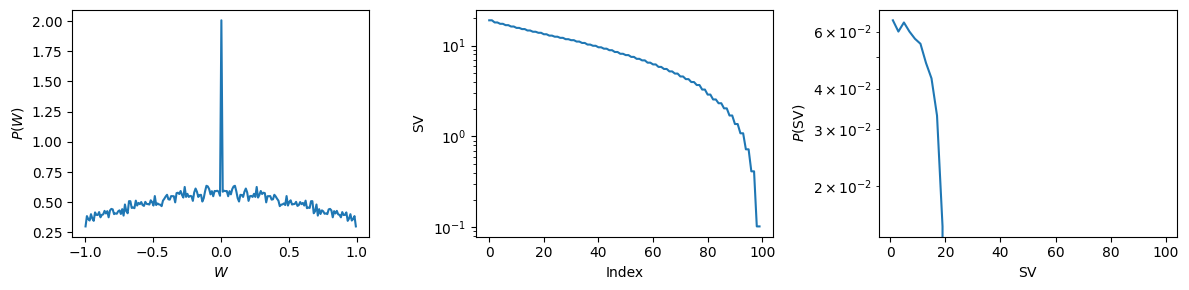

In [12]:
_, axes = plt.subplots(1, 3, figsize=(12, 3))
w_bins = np.linspace(-1, 1, 201)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.linspace(0, 100, 51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]
for tf in [1]:
    sv, arr, spec = average_curves(generate_so_n, d_n=100)
    axes[0].plot(w_centers, arr)
    axes[0].set_xlabel("$W$")
    axes[0].set_ylabel("$P(W)$")

    axes[1].plot(sv)
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel("$\mathrm{SV}$")
    axes[1].set_yscale("log")

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel("$\mathrm{SV}$")
    axes[2].set_ylabel("$P(\mathrm{SV})$")
    axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

## Entropy Studies

/opt/anaconda3/envs/llm-work/lib/python3.11/site-packages/scipy/stats/_entropy.py:381: RuntimeWarning: divide by zero encountered in log
  logs = xp.log(n/(2*m) * differences)
/var/folders/_5/w5f7n1zx5t521cn85gjbd2400000gn/T/ipykernel_23343/4123087778.py:17: RuntimeWarning: divide by zero encountered in log
  plt.plot(x_vals, 0.5*(np.log(2*np.pi*np.e*x_vals/d_model)), '--', label=r'$\frac{1}{2}\ln 2\pi e d/d_{\text{model}}$')


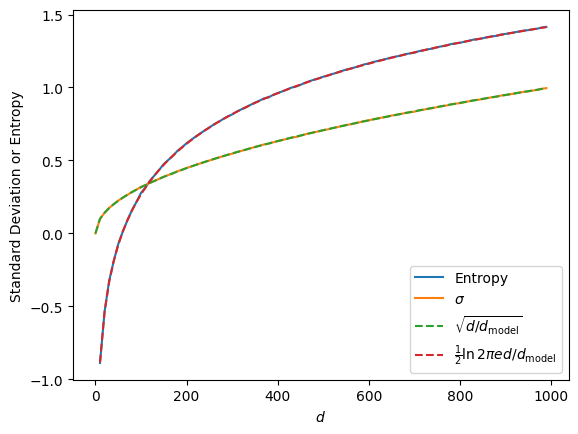

In [13]:
def generate_low_rank_2(d_n, d_m, mu=0, sigma=1):
    W_Q = np.random.normal(loc=mu, scale=sigma, size=d_n * d_m).reshape(d_n, d_m)
    W_K = np.random.normal(loc=mu, scale=sigma, size=d_n * d_m).reshape(d_m, d_n)
    W_QK = W_Q @ W_K / np.sqrt(d_n)
    W_QK = W_QK.flatten()
    sigma = np.std(W_QK)
    entropy = differential_entropy(W_QK)
    return sigma, entropy
d_model = 1000
n_steps = 10
results = [generate_low_rank_2(d_model,d_m) for d_m in range(0,d_model,n_steps)]
x_vals =np.array([d_m for d_m in range(0,d_model,n_steps)])
sig, ent = zip(*results)
plt.plot(x_vals, ent, label='Entropy')
plt.plot(x_vals, sig, label=r'$\sigma$')
plt.plot(x_vals, np.sqrt(x_vals/d_model), '--', label=r'$\sqrt{d/d_{\text{model}}}$')
plt.plot(x_vals, 0.5*(np.log(2*np.pi*np.e*x_vals/d_model)), '--', label=r'$\frac{1}{2}\ln 2\pi e d/d_{\text{model}}$')
plt.xlabel('$d$')
plt.ylabel('Standard Deviation or Entropy')
plt.legend()

# Singular values as test statistics

### Helper functions to compute statistics from singular values

In [14]:
def compute_sv_stat(sv, stat_type, d_model, d_head):
    if stat_type == "mean":
        return np.mean(sv)
    elif stat_type == "max":
        return np.max(sv)
    elif stat_type == "variance":
        return np.var(sv)
    elif stat_type == "sum":
        return np.sum(sv)
    elif stat_type == "sum_squares":
        return np.sum(sv**2)
    elif stat_type == "participation_ratio":
        sum_sv = np.sum(sv)
        sum_sv2 = np.sum(sv**2)
        return (sum_sv**2) / sum_sv2 if sum_sv2 > 0 else 0
    elif stat_type == "normalized_participation_ratio":
        sum_sv = np.sum(sv)
        sum_sv2 = np.sum(sv**2)
        participation_ratio = (sum_sv**2) / sum_sv2 if sum_sv2 > 0 else 0
        return participation_ratio / d_head if d_head > 0 else 0
    elif stat_type == "spectral_entropy":
        sv2 = sv**2
        sum_sv2 = np.sum(sv2)
        if sum_sv2 > 0:
            p = sv2 / sum_sv2
            p = p[p > 0]  # Remove zeros to avoid log(0)
            return -np.sum(p * np.log(p))
        return 0
    elif stat_type == "condition_number":
        # Use only the d_head largest SVs (low-rank structure)
        sv_nonzero = sv[:d_head]
        if len(sv_nonzero) > 0 and sv_nonzero[-1] > 0:
            return sv_nonzero[0] / sv_nonzero[-1]
        return 0
    elif stat_type == "stable_rank":
        sum_sv2 = np.sum(sv**2)
        max_sv2 = sv[0]**2
        return sum_sv2 / max_sv2 if max_sv2 > 0 else 0

    return 0

In [15]:
def collect_sv_stats(d_model, d_head, n_samples=500, sigma=1.0):
    """Generate n_samples random low-rank W_QK and compute SVD statistics for each."""
    stat_names = [
        "max", "participation_ratio", "normalized_participation_ratio",
        "spectral_entropy", "condition_number", "stable_rank"
    ]
    stats = {k: np.zeros(n_samples) for k in stat_names}
    for i in range(n_samples):
        S, _, _ = generate_low_rank(d_model, d_head, mu=0, sigma=sigma)
        S_np = S.numpy() if hasattr(S, 'numpy') else np.array(S)
        for k in stat_names:
            stats[k][i] = compute_sv_stat(S_np, k, d_model, d_head)
    return stats


def plot_stat_distributions(stats, d_model, d_head, n_bins=40):
    """Plot histograms of each SVD statistic."""
    nice_names = {
        "max": r"$\lambda_{\max}$",
        "participation_ratio": r"Participation ratio $(\sum \lambda)^2 / \sum \lambda^2$",
        "normalized_participation_ratio": r"Normalized PR / $d_h$",
        "spectral_entropy": r"Spectral entropy $-\sum p_i \ln p_i$",
        "condition_number": r"Condition number $\lambda_1 / \lambda_{d_h}$",
        "stable_rank": r"Stable rank $\sum \lambda^2 / \lambda_{\max}^2$",
    }
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    for idx, (key, vals) in enumerate(stats.items()):
        ax = axes[idx]
        ax.hist(vals, bins=n_bins, density=True, alpha=0.7, edgecolor='k', linewidth=0.3)
        ax.set_xlabel(nice_names.get(key, key), fontsize=10)
        ax.set_ylabel("Density")
        mean, std = np.mean(vals), np.std(vals)
        ax.axvline(mean, color='red', ls='--', lw=1.2, label=f"mean={mean:.2f}")
        ax.legend(fontsize=8)
        ax.set_title(f"d={d_model}, d_h={d_head}", fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

### SVD statistic distributions for random low-rank matrices

Sample many random $W_{QK}$ matrices at fixed $(d, d_h)$ and plot the probability distributions of SVD-derived statistics: leading singular value, participation ratio, normalized participation ratio, spectral entropy, condition number, and stable rank. This gives a feel for the expected spread and shape before looking at trained models.

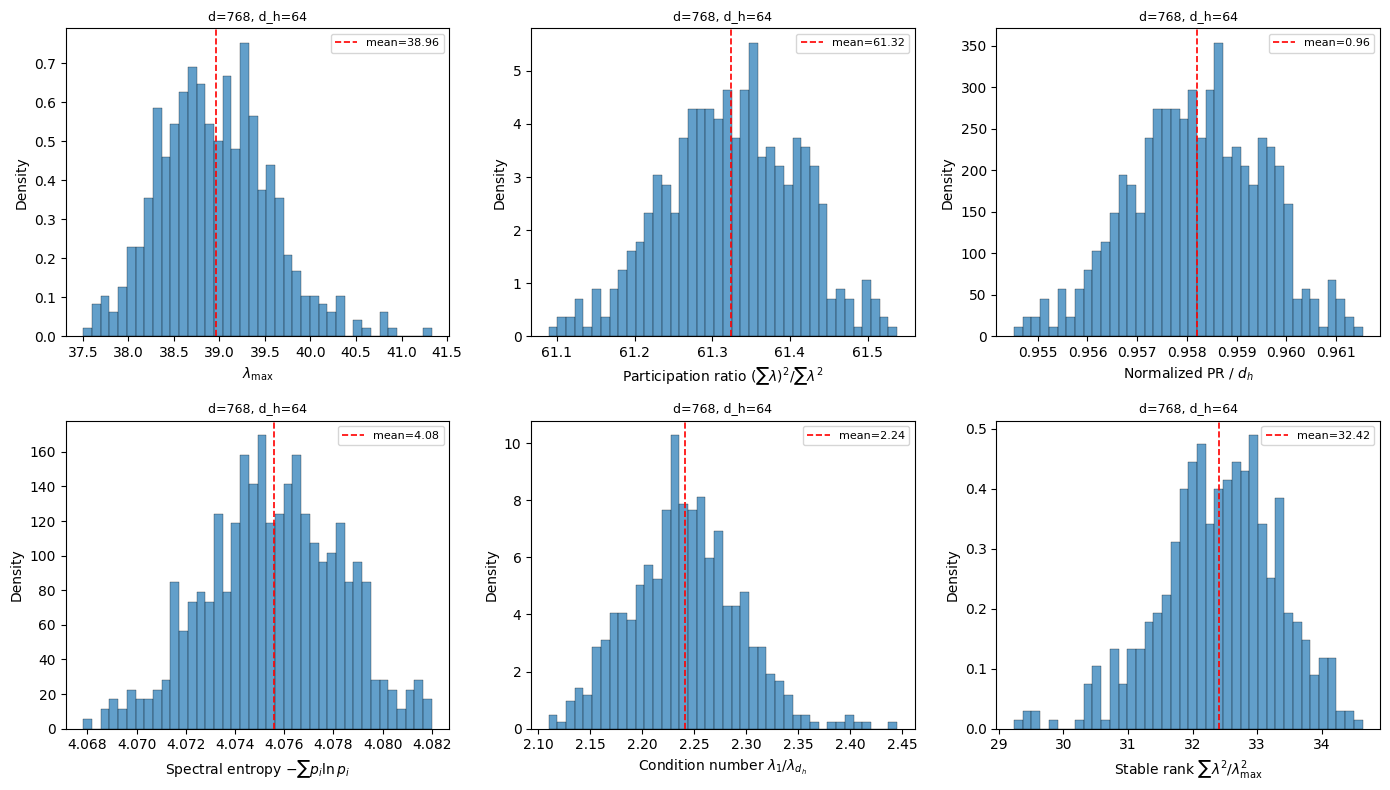

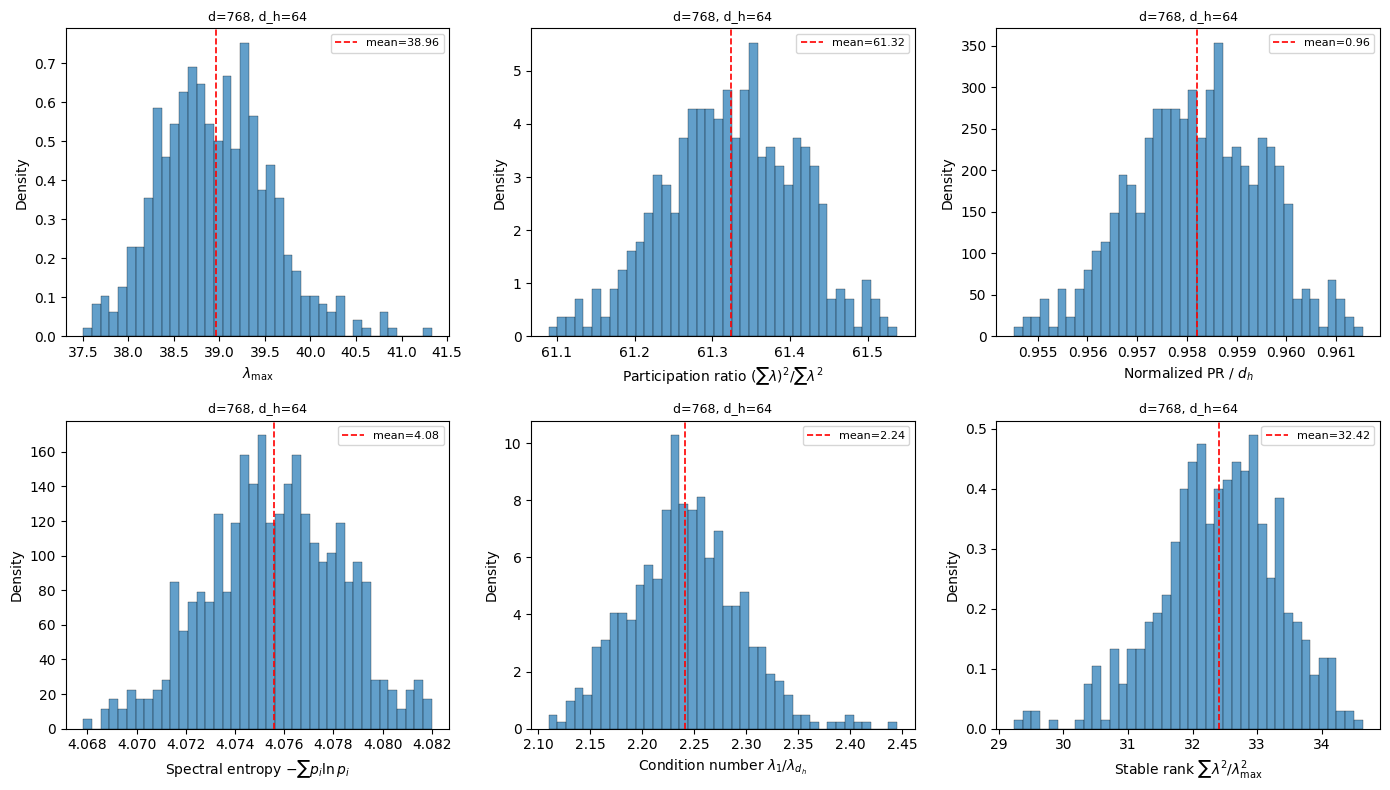

In [16]:
# Single configuration: GPT-2 scale (d=768, d_h=64)
stats_gpt2 = collect_sv_stats(d_model=768, d_head=64, n_samples=500)
plot_stat_distributions(stats_gpt2, d_model=768, d_head=64)

In [17]:
# Compare across d_h values at fixed d=768 (like varying n_h = 1, 2, 4, 8, 12, 16, 32)
d_model = 768
d_h_values = [768, 384, 192, 96, 64, 48, 24]  # n_h = 1, 2, 4, 8, 12, 16, 32
n_samples = 300

stat_names = ["max", "participation_ratio", "normalized_participation_ratio",
              "spectral_entropy", "condition_number", "stable_rank"]
nice_names = {
    "max": r"$\lambda_{\max}$",
    "participation_ratio": r"PR $= (\sum \lambda)^2 / \sum \lambda^2$",
    "normalized_participation_ratio": r"Normalized PR / $d_h$",
    "spectral_entropy": r"Spectral entropy",
    "condition_number": r"Condition number $\lambda_1 / \lambda_{d_h}$",
    "stable_rank": r"Stable rank",
}

all_stats = {}
for d_h in d_h_values:
    print(f"d_h = {d_h} (n_h = {d_model // d_h})...")
    all_stats[d_h] = collect_sv_stats(d_model, d_h, n_samples=n_samples)

# MP predictions for each d_h
mp_preds = {d_h: mp_sv_predictions(d_model, d_h) for d_h in d_h_values}

# Box plot comparison with MP overlay
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, stat in enumerate(stat_names):
    ax = axes[idx]
    data = [all_stats[d_h][stat] for d_h in d_h_values]
    labels = [f"{d_h}\n({d_model//d_h}h)" for d_h in d_h_values]
    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.6)
    for patch, d_h in zip(bp['boxes'], d_h_values):
        patch.set_facecolor(plt.cm.viridis(d_h / d_model))
        patch.set_alpha(0.6)
    # Overlay MP predictions as red stars
    mp_vals = [mp_preds[d_h].get(stat, np.nan) for d_h in d_h_values]
    x_positions = range(1, len(d_h_values) + 1)
    ax.plot(x_positions, mp_vals, 'r*', markersize=12, zorder=5, label="MP prediction")
    ax.set_xlabel(r"$d_h$ ($n_h$)")
    ax.set_ylabel(nice_names[stat])
    ax.set_title(nice_names[stat], fontsize=10)
    ax.legend(fontsize=7, loc='best')
fig.suptitle(f"SVD statistics vs $d_h$ at $d$ = {d_model}, random $W_{{QK}}$ (boxes) vs MP (stars)", fontsize=11)
plt.tight_layout()
plt.show()

d_h = 768 (n_h = 1)...
d_h = 384 (n_h = 2)...
d_h = 192 (n_h = 4)...
d_h = 96 (n_h = 8)...
d_h = 64 (n_h = 12)...
d_h = 48 (n_h = 16)...
d_h = 24 (n_h = 32)...


NameError: name 'mp_sv_predictions' is not defined

In [ ]:
# Means and relative widths vs d_h, with MP predictions overlaid
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, stat in enumerate(stat_names):
    ax = axes[idx]
    means = [np.mean(all_stats[d_h][stat]) for d_h in d_h_values]
    stds = [np.std(all_stats[d_h][stat]) for d_h in d_h_values]
    mp_vals = [mp_preds[d_h].get(stat, np.nan) for d_h in d_h_values]
    ax.errorbar(d_h_values, means, yerr=stds, fmt='o-', capsize=3, color='steelblue', label='MC samples')
    ax.plot(d_h_values, mp_vals, 'r*--', markersize=10, label='MP prediction')
    ax.set_xlabel(r"$d_h$")
    ax.set_ylabel(nice_names[stat])
    ax.set_title(nice_names[stat], fontsize=10)
    ax.legend(fontsize=8)
    # secondary x-axis for n_h
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(d_h_values)
    ax2.set_xticklabels([str(d_model // d_h) for d_h in d_h_values], fontsize=7)
    ax2.set_xlabel(r"$n_h$", fontsize=8)
fig.suptitle(f"Mean ± std of SVD statistics vs $d_h$, d = {d_model}", fontsize=12)
plt.tight_layout()
plt.show()

### Implementation of Marchenko-Pastur Distributions

In [ ]:
def marchenko_pastur_density(s, d, r):
    gamma = r / d
    
    # Corrected: singular values scale like sqrt(d), not sqrt(r)
    s_min = np.sqrt(d) * (1 - np.sqrt(gamma))
    s_max = np.sqrt(d) * (1 + np.sqrt(gamma))
    
    s = np.asarray(s)
    rho = np.zeros_like(s, dtype=float)
    
    mask = (s >= s_min) & (s <= s_max)
    s_masked = s[mask]
    
    rho[mask] = (1 / (np.pi * d)) * \
                np.sqrt((s_max**2 - s_masked**2) * (s_masked**2 - s_min**2)) / s_masked
    
    return rho

In [ ]:
def mp_sv_predictions(d, d_h, sigma=1.0, n_quad=5000):
    """Compute analytic/numerical MP predictions for SVD statistics.
    
    Uses MP edges for lambda_max, lambda_min, condition number.
    Numerical integration over MP density for PR, stable rank, spectral entropy.
    """
    gamma = d_h / d
    
    # MP edges for singular values
    lam_min = np.sqrt(d) * (1 - np.sqrt(gamma)) * sigma
    lam_max = np.sqrt(d) * (1 + np.sqrt(gamma)) * sigma
    
    # Condition number from edges
    cond = lam_max / lam_min if lam_min > 0 else np.inf
    
    # Numerical integration over MP density
    s_grid = np.linspace(lam_min + 1e-10, lam_max - 1e-10, n_quad)
    rho = marchenko_pastur_density(s_grid, d * sigma**2, d_h)
    ds = s_grid[1] - s_grid[0]
    
    # Normalization (should be ~1 for per-SV density)
    norm = np.trapz(rho, s_grid)
    
    # Moments per SV, then scale by d_h
    E_lam = np.trapz(s_grid * rho, s_grid)
    E_lam2 = np.trapz(s_grid**2 * rho, s_grid)
    sum_lam = E_lam * d_h / norm if norm > 0 else 0
    sum_lam2 = E_lam2 * d_h / norm if norm > 0 else 0
    
    # Participation ratio
    pr = sum_lam**2 / sum_lam2 if sum_lam2 > 0 else 0
    npr = pr / d_h if d_h > 0 else 0
    
    # Stable rank
    stable_rank = sum_lam2 / lam_max**2 if lam_max > 0 else 0
    
    # Spectral entropy via quantile sampling of the MP density
    cdf = np.cumsum(rho * ds)
    cdf = cdf / cdf[-1]
    u = np.linspace(0, 1, d_h + 2)[1:-1]  # d_h quantiles
    sv_quantiles = np.interp(u, cdf, s_grid)
    p_discrete = sv_quantiles**2 / np.sum(sv_quantiles**2)
    p_discrete = p_discrete[p_discrete > 0]
    spectral_entropy = -np.sum(p_discrete * np.log(p_discrete))
    
    return {
        "max": lam_max,
        "condition_number": cond,
        "participation_ratio": pr,
        "normalized_participation_ratio": npr,
        "stable_rank": stable_rank,
        "spectral_entropy": spectral_entropy,
        "lam_min": lam_min,
        "sum_lam": sum_lam,
        "sum_lam2": sum_lam2,
    }

# Sanity check at GPT-2 scale
pred = mp_sv_predictions(768, 64)
for k, v in pred.items():
    print(f"  {k}: {v:.4f}")

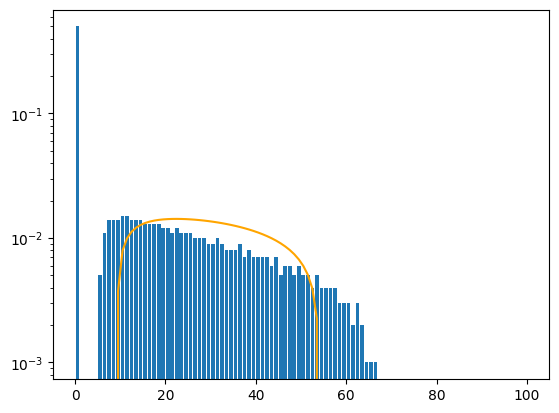

In [ ]:
dmax = 1000
d_h = 500
sv, arr, spec = average_curves(generate_low_rank, d_n=dmax,d_m=d_h, sigma=1, n_samp=20)
xbins = np.linspace(0,100,101)
xcenters = 0.5*(xbins[:-1] + xbins[1:])
hist, _ = np.histogram(sv, bins=xbins, density=True)
yvals = marchenko_pastur_density(xcenters, d=dmax, r=d_h)
plt.bar((xbins[:-1]+xbins[1:])*0.5,hist)
plt.yscale("log")
plt.plot(xcenters, yvals, c='orange')